In [18]:
#reset all variables
%reset -f

In [19]:
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver, RadioMapSolver, AntennaPattern, register_antenna_pattern
import numpy as np
import matplotlib.pyplot as plt
import mitsuba as mi
import drjit as dr

In [20]:
scene = load_scene("scene/final_scene_windows.xml",merge_shapes=False)
scene.frequency = 40e9 #Hz
scene.synthetic_array = True

# for name, obj in scene.objects.items():
#     print(f'{name:<15}{obj.radio_material.name}')

In [21]:
# Configure antenna array
scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=4,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization = "V")


scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V")

#Create transmitter and receiver
tx = Transmitter(name="tx",
                 position=mi.Point3f(-7, 0, 1),
                 orientation=mi.Point3f(0, 0, 0),
                 power_dbm=37)
scene.add(tx)
tx.look_at([-6, 0, 2])
nReceptor = 22
positions = ( (-6.5 , 4),   #1
              (-4   , 3),   #2
              (-2   , 3),   #3
              (0    , 3),   #4
              (1    , 1.2), #5
              (-2   , 1.2), #6
              (-6   , 1.2), #7
              (-4.5 , 1.2), #7b
              (-5.3 , -0.5),#8
              (-2.5 , 0.2), #9
              (0.5  , 0.5), #10
              (2.5  , 1),   #11
              (3    , -1),  #12
              (1    , -2),  #13
              (-2   , -2),  #14
              (-5.3 , -2.5),#15
              (-7   , -2.5),#16
              (-5.7 , -4),  #17
              (-4   , -4),  #17b
              (-2   , -4),  #18
              (1    , -4),  #19
              (3    , -4))  #20
for i in range(nReceptor):
    posx = positions[i][0]
    posy = positions[i][1]
    posz = 1
    rx = Receiver(name=f"rx_{i}",
                 position=mi.Point3f(posx, posy, posz),
                 orientation=mi.Point3f(0.0, 0.0, 0.0))
    scene.add(rx)

In [28]:
#Compute propagation paths
solver  = PathSolver()
paths = solver(scene,samples_per_src=int(1e6))

scene.preview()

In [29]:
#Compute Radio Map
rmSolver = RadioMapSolver()

# rm = rmSolver(scene, cell_size=(.005, .005), samples_per_tx= int(1e8))
# scene.preview(radio_map=rm, clip_at=15., rm_vmin=-100.)

#Other way to compute it, less details
rm = rmSolver(scene, max_depth=3, cell_size=[0.05, 0.05])
scene.preview(radio_map=rm, clip_at=15., rm_vmin=-100.)
#scene.preview(radio_map=rm)

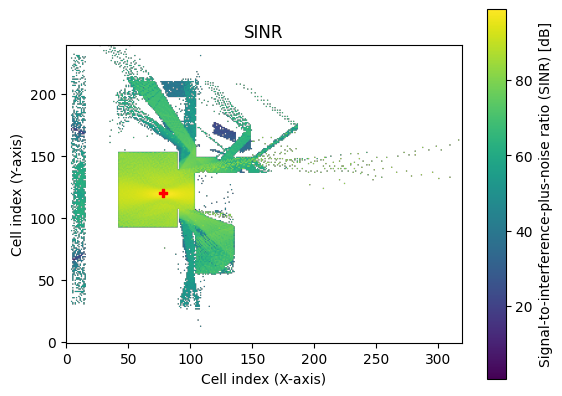

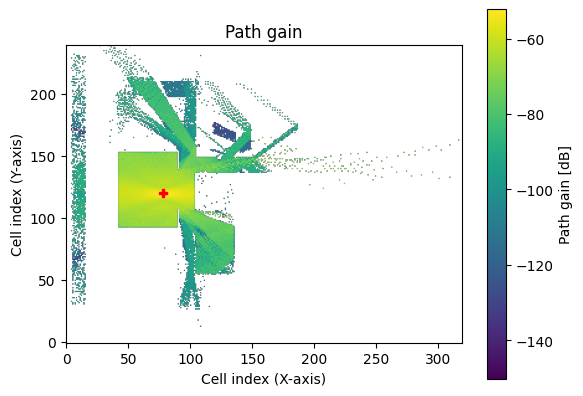

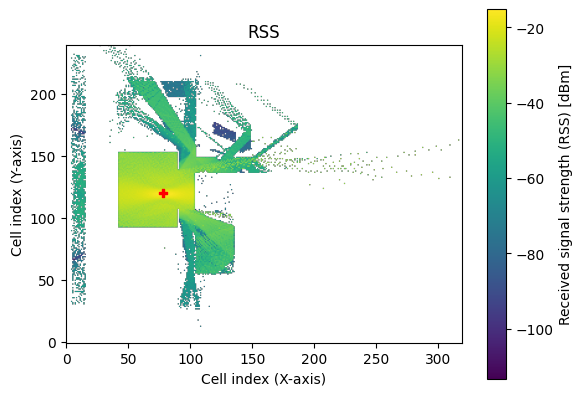

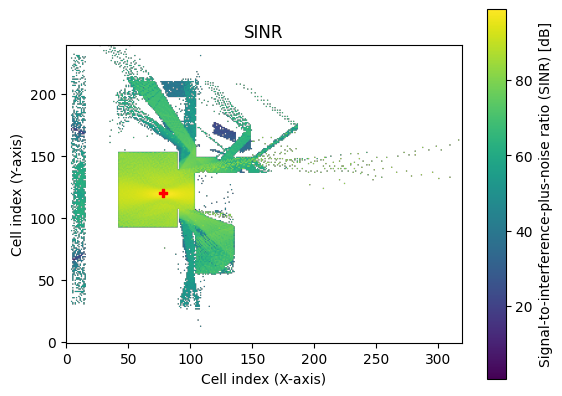

In [24]:
rm.show(metric='path_gain')
rm.show(metric='rss')
rm.show(metric='sinr')

In [40]:
# Extract CIR, complex amplitudes and time delay
# a, tau = paths.cir()
#
# amplitudesFix = a[0][0].numpy()
# delaysFix = tau[0][0].numpy()
#
# amplitudes = np.squeeze(amplitudesFix)
# delays = np.squeeze(delaysFix)
#
# validPaths = delays > 0
# validDelays = delays[validPaths]
# validAmplitudes = amplitudes[validPaths]
#
# dBPower = 10*np.log10(np.abs(validAmplitudes)**2 + 1e-12)
# delayInNs = validDelays*1e9
#
# #Power Delay Profile
# plt.figure()
# plt.stem(delayInNs, dBPower, basefmt=" ", linefmt="blue", markerfmt="bo")
# plt.title("Channel Impulse Response (CIR) at 40 GHz")
# plt.xlabel("ToF (ns)")
# plt.ylabel("Received Power (dB)")
# plt.grid(True)
# plt.show()
#
# print(f"All captured paths: {len(validPaths)}")
# for i in range(len(validDelays)):
#     print(f"Path {i+1}, Delay = {delayInNs[i]:.2f} ns, Power = {dBPower[i]:.2f} dB")